In [1]:
# add src3 to sys.path for imports
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / "src3"))

In [23]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from io_utils import save, load, append, preview, Timing, get_box_coverage_key
from overhead_pipeline import app, capture_overhead, process_overhead, visualize_overhead
from vibrations_pipeline import capture_vibrations

In [3]:
# Run once after kernel restart — keeps Modal app alive for the whole session.
# Must use async with app.run.aio() in Jupyter; the sync app.run() fights Jupyter's event loop.
# _app_ctx holds the context manager so it isn't garbage collected (which would stop the app).
_app_ctx = app.run.aio()
await _app_ctx.__aenter__()

In [11]:
EXPERIMENT_DIR = Path('/home/ethantu/workspace/good-vibrations/data2')
BASE_SAMPLE_DIR = Path(EXPERIMENT_DIR) / 'samples'
BASE_OUTPUT_DIR = Path(EXPERIMENT_DIR) / 'outputs'

for path in [BASE_SAMPLE_DIR, BASE_OUTPUT_DIR]: os.makedirs(path, exist_ok=True)

In [12]:
def count_dirs(path): return sum(1 for path in path.iterdir() if path.is_dir()) if path.exists() else 0
def make_id(path): return f"{count_dirs(path):06d}"

In [36]:
def show_box_coverage(box_coverage:dict, sample_dir:str|Path=None, verbose:int=1):
    metadata = {'sample_id': ''} if sample_dir is None else {k: v for d in load(sample_dir / "metadata.jsonl") for k, v in d.items()}
    with Timing(f"[Sample {metadata['sample_id']}] box coverage: ", enabled=verbose>=2):
        if sample_dir is not None:
            mask = np.array(load(sample_dir / "outputs/02_segment_mask.png"))

            # update box coverage
            key = get_box_coverage_key(metadata, mask)
            if key not in box_coverage: box_coverage[key] = {'mask': np.zeros(mask.shape), 'sample_ids': []}
            box_coverage[key]['mask'] += mask
            box_coverage[key]['sample_ids'].append(metadata['sample_id'])

            keys = [key]
        else:
            keys = box_coverage.keys()

    return box_coverage

In [16]:
# initialize box coverage
box_coverage = {}
for sample_dir in BASE_SAMPLE_DIR.iterdir(): box_coverage = show_box_coverage(box_coverage, sample_dir, plot=False)
show_box_coverage(box_coverage, plot=True)
plt.show()

[Sample ] box coverage:   0.00 ms


In [17]:
def save_experiment(experiment_name, image, frame_recording, run_opt, speakers, object, n_objects, box_material, meow):

    experiment_params = {
        "ROI_ROW_HEIGHT": ROI_ROW_HEIGHT,
        "N_ROI_ROWS": N_ROI_ROWS,
        "N_ROI_COLUMNS": N_ROI_COLUMNS,
        "ROI_COLUMN_WIDTH": ROI_COLUMN_WIDTH,
        "CALIBRATION_FPS": CALIBRATION_FPS,
        "CALIBRATION_EXPOSURE": CALIBRATION_EXPOSURE,
        "CALIBRATION_GAIN": CALIBRATION_GAIN,
        "EXPOSURE": EXPOSURE,
        "GAIN": GAIN,
        "BUFFER_PART_COUNT": BUFFER_PART_COUNT,
        "EXPOSURE_MS": EXPOSURE_MS,
        "FRAME_RATE": FRAME_RATE,
        "PIXEL_CLOCK": PIXEL_CLOCK,
        "CAMERA_GAIN": CAMERA_GAIN,
        "RESIZE_FACTOR": RESIZE_FACTOR,
        "GAMMA": GAMMA,
    }



    # save overhead box image
    filepath = os.path.join(out_dir, 'box_overhead_image.png')
    cv2.imwrite(filepath, image)
    print(f'Saved box overhead image to: {filepath}')

    # Save frame recording
    frame_recording_filepath = os.path.join(out_dir, f'frame-recording.npy')
    np.save(frame_recording_filepath, frame_recording)
    print(f'Saved {frame_recording.shape[0]} data samples to: {frame_recording_filepath}')

    # Save metadata
    metadata_filepath = os.path.join(out_dir, f'metadata.npz')
    run_opt['run_opt_multiROIs'] = run_opt_multiROIs
    np.savez(metadata_filepath, experiment_name=experiment_name, run_opt=run_opt)
    print(f'Saved metadata to: {metadata_filepath}')

    # Save config
    params_filepath = os.path.join(out_dir, f'experiment_config.json')
    with open(params_filepath, 'w') as f:
        json.dump(experiment_config, f, indent=4)
    print(f'Saved experiment config to: {params_filepath}')

    print('Experiment saved successfully!')
    if meow:
        winsound.PlaySound('..\\data\\audio_samples\\meow.wav', winsound.SND_FILENAME | winsound.SND_ASYNC)

    return True

In [ ]:
def run_experiment(obj_params, overhead_params, vibrate_params, box_coverage, cam, run_opt, overhead_cam, capture_image_fxn, play_audio_fxn, capture_n_frames_fxn, verbose:int=1, do_save:bool=True):

    # initial values
    output_id = make_id(BASE_OUTPUT_DIR)
    output_dir = BASE_OUTPUT_DIR / output_id
    is_empty_box = obj_params['n_objects'] == 0
    metadata = obj_params | overhead_params | dict(output_dir=str(output_dir), output_id=output_id, is_empty_box=is_empty_box)
    append([{str(k) if isinstance(k, Path) else k: v} for k, v in metadata.items()], output_dir / 'metadata.jsonl', do_save)
    speakers = vibrate_params['speakers'] if isinstance(vibrate_params['speakers'], list) else [vibrate_params['speakers']]

    # overhead image
    with Timing(f"[output {output_id}] total time: ", enter=f"[output {output_id}] start", enabled=verbose>=1):
        # capture overhead image
        raw_overhead = capture_overhead(overhead_cam, capture_image_fxn, output_dir, do_save=do_save)

        # process overhead image (resize, segment, center of mass)
        process_overhead(raw_overhead, output_dir, **overhead_params['resize_params'], prompt=overhead_params['prompt'], is_empty_box=is_empty_box, verbose=verbose, do_save=do_save)

    # loop over all speakers
    for speaker in speakers:
        sample_id  = make_id(BASE_SAMPLE_DIR)
        sample_dir = BASE_SAMPLE_DIR / sample_id
        with Timing(f"[sample {sample_id}] total time: ", enter=f"[sample {sample_id}] start", enabled=verbose>=1):

            # overhead image viz
            overhead = visualize_overhead(speaker, sample_dir, output_dir, is_empty_box, verbose, do_save=do_save)
            if verbose >= 1: preview(overhead, 'image')

            # box coverage viz
            box_coverage = show_box_coverage(box_coverage, sample_dir, verbose)
            if verbose >= 1: preview((box_coverage, sample_dir), 'box_coverage')

            # capture vibrations
            raw_vibrations = capture_vibrations(cam, run_opt, speaker, play_audio_fxn, capture_n_frames_fxn, vibrate_params['audio'], sample_dir, output_dir, verbose=verbose, do_save=do_save)
            if verbose >= 1: preview(raw_vibrations, 'vibration_image')
            if verbose >= 3: preview(raw_vibrations, 'vibration_video')

            # process_vibrations(raw_vibrations) # launch pclk

[output 000008] start
[output 000008] total time: 2145.23 ms
[sample 000016] start


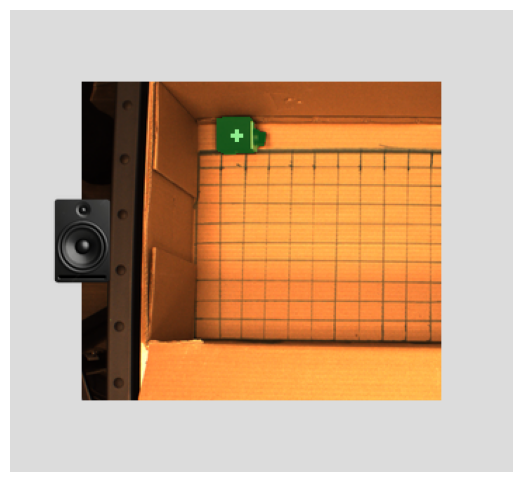

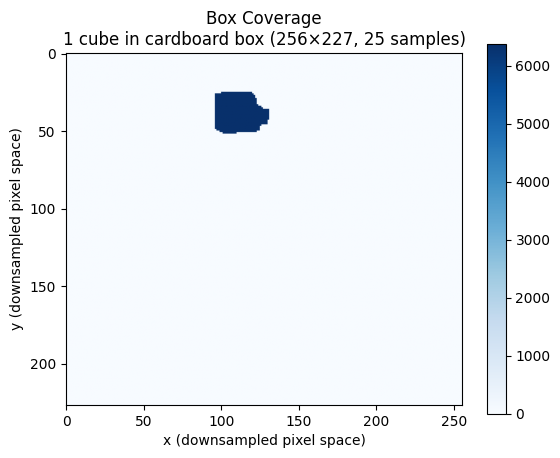

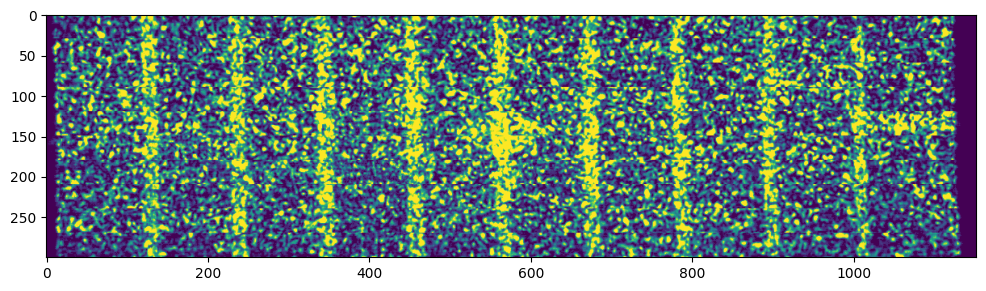

[sample 000016] total time: 1068.85 ms
[sample 000017] start


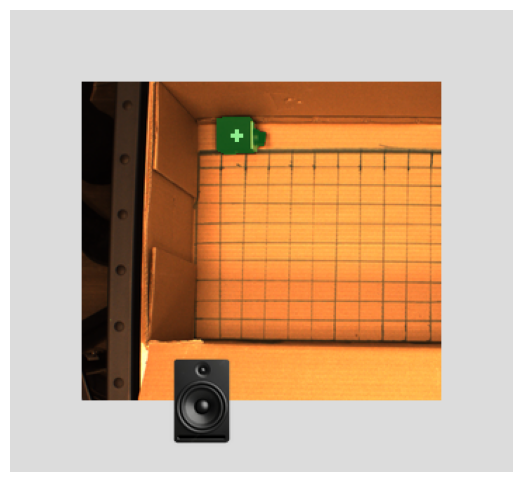

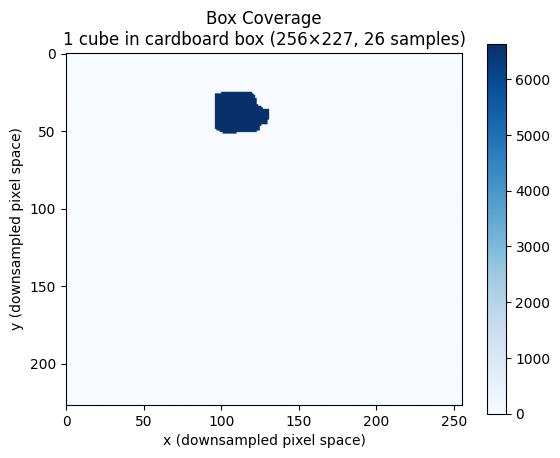

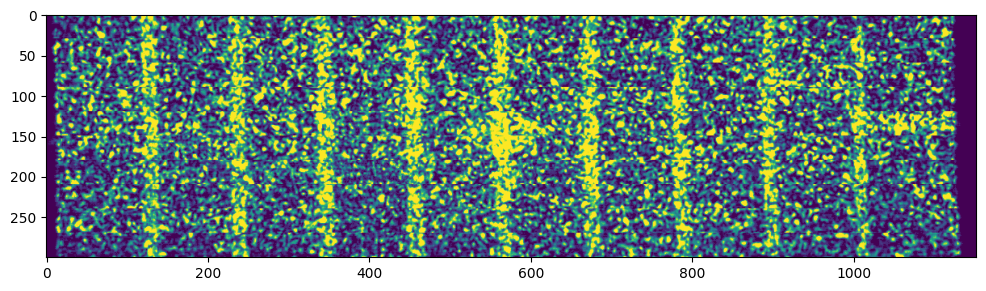

[sample 000017] total time: 1335.50 ms
[samples 16-17] total time: 4555.43 ms


In [45]:
box = 'cardboard'
object = 'cube'
n_objects = 1
prompt = "A black metal cube sitting on the floor of an open cardboard box from a bird's eye view."
description = prompt
resize_params = {"left": 0.05, "right": 0.59, "up": 0.06, "down": 0.7, "max_side": 256}
laser_camera_fps = 2_500
audio = Path('/home/ethantu/workspace/good-vibrations/data2/chirp_50_1000_3.0sec.wav')
verbose = 1

obj_params = dict(object=object, n_objects=n_objects, box=box)
overhead_params = dict(prompt=prompt, description=description, resize_params=resize_params)
vibrate_params = dict(audio=audio, laser_camera_fps=laser_camera_fps, speakers=[3, 4])

# define dummy functions
def capture_image_fxn(x):
    img = load('/home/ethantu/workspace/good-vibrations/data2/00_raw_overhead.png')
    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR), None
def play_audio_fxn(x, y): pass
def capture_n_frames_fxn(x, y, *args): return load('/home/ethantu/workspace/good-vibrations/data2/speckle_vibration_raw.npy'), None

# define dummy parameters
overhead_cam = None
run_opt = {'cam_params': {'camera_FPS': 5000}}
class cam:
    def __init__(self): pass
    def get_im_size(self): return [0]

start_sample, end_sample = int(make_id(BASE_SAMPLE_DIR)), int(make_id(BASE_SAMPLE_DIR)) + len(vibrate_params['speakers']) - 1
with Timing(f"[samples {start_sample}-{end_sample}] total time: ", enabled=verbose>=1):
    run_experiment(obj_params, overhead_params, vibrate_params, box_coverage, cam(), run_opt, overhead_cam, capture_image_fxn, play_audio_fxn, capture_n_frames_fxn, verbose=verbose)

In [ ]:
output_id = make_id(BASE_OUTPUT_DIR)
output_dir = BASE_OUTPUT_DIR / output_id
speaker = vibrate_params['speakers'][0]
sample_id  = make_id(BASE_SAMPLE_DIR)
sample_dir = BASE_SAMPLE_DIR / sample_id
verbose = 2
do_save= True

raw_vibrations = capture_vibrations(cam(), run_opt, speaker, play_audio_fxn, capture_n_frames_fxn, vibrate_params['audio'], sample_dir, output_dir, verbose=verbose, do_save=do_save)